# Bayesian Alpha Beta Back Test vs Going-Long Comparison

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from src.config import DATA_PATH

portfolio_path = DATA_PATH / 'bt_4555split_portfolio.parquet'
per_ticker_path = DATA_PATH / 'bt_4555split_per_ticker.parquet'
summary_path = DATA_PATH / 'bt_4555split_summary.parquet'

def load_data():
    portfolio = pd.read_parquet(portfolio_path)
    portfolio.index = pd.to_datetime(portfolio.index)
    per_ticker = pd.read_parquet(per_ticker_path)
    per_ticker.index.name = 'Ticker'
    summary = pd.read_parquet(summary_path)
    return portfolio, per_ticker, summary

portfolio_df_wo, per_ticker_df, summary_df = load_data()

## Portfolio Equity Curves

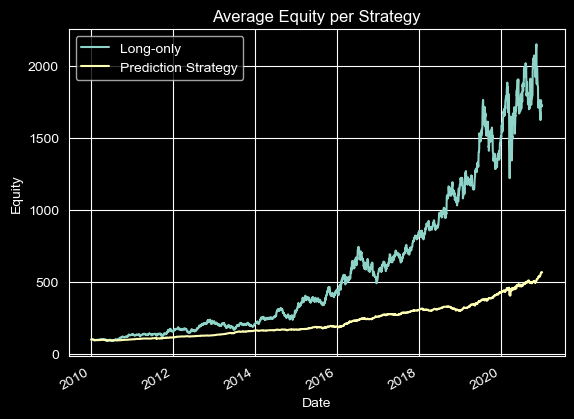

In [6]:
ax = portfolio_df_wo[['equity_long', 'equity_strategy']].plot()
ax.set_title('Average Equity per Strategy')
ax.set_ylabel('Equity')
ax.legend(['Long-only', 'Prediction Strategy'])
plt.show()

## Summary

In [7]:
summary_df

,value
portfolio_long_final_equity,1725.109603
portfolio_strategy_final_equity,566.496422
portfolio_long_cagr,0.295843
portfolio_strategy_cagr,0.170864
portfolio_long_max_drawdown,-0.352229
portfolio_strategy_max_drawdown,-0.119285
portfolio_avg_daily_excess_ret,-0.000421


# Results Without Outlier

In [16]:
bt_daily = pd.read_parquet(DATA_PATH / "bt_4555split.parquet")
long_daily = pd.read_parquet(DATA_PATH / "going_long_data.parquet")

bt_daily = bt_daily[bt_daily["Ticker"] != "NST.AX"].copy()
long_daily = long_daily[long_daily["Ticker"] != "NST.AX"].copy()

portfolio_df_wo_wo = (
    long_daily.groupby("Date")["equity"].mean().to_frame("equity_long").join(bt_daily.groupby("Date")["equity"].mean().to_frame("equity_strategy"), how="inner"))
portfolio_df_wo.index = pd.to_datetime(portfolio_df_wo.index)

## Portfolio Equity Curve Without Outlier

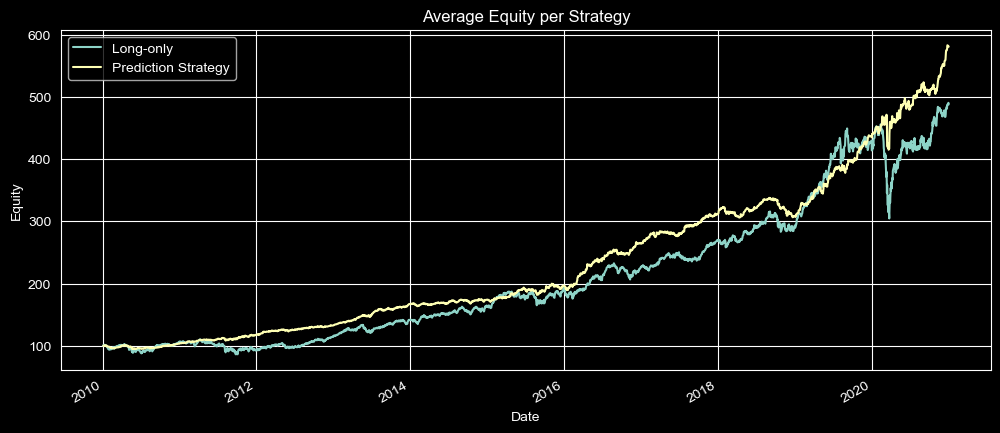

In [17]:
ax = portfolio_df_wo_wo[["equity_long", "equity_strategy"]].plot(figsize=(12, 5))
ax.set_title("Average Equity per Strategy")
ax.set_ylabel("Equity")
ax.legend(["Long-only", "Prediction Strategy"])
plt.show()

## Summary Without Outlier

In [20]:
span_years = (portfolio_df_wo.index[-1] - portfolio_df_wo.index[0]).days / 365.0
summary_df = pd.Series({
    "portfolio_long_final_equity": portfolio_df_wo["equity_long"].iloc[-1],
    "portfolio_strategy_final_equity": portfolio_df_wo["equity_strategy"].iloc[-1],
    "portfolio_long_cagr": (portfolio_df_wo["equity_long"].iloc[-1] / portfolio_df_wo["equity_long"].iloc[0]) ** (1 / span_years) - 1,
    "portfolio_strategy_cagr": (portfolio_df_wo["equity_strategy"].iloc[-1] / portfolio_df_wo["equity_strategy"].iloc[0]) ** (1 / span_years) - 1,
    "portfolio_long_max_drawdown": (portfolio_df_wo["equity_long"] / portfolio_df_wo["equity_long"].cummax() - 1).min(),
    "portfolio_strategy_max_drawdown": (portfolio_df_wo["equity_strategy"] / portfolio_df_wo["equity_strategy"].cummax() - 1).min(),
    "portfolio_avg_daily_excess_ret": (portfolio_df_wo["equity_strategy"].diff() - portfolio_df_wo["equity_long"].diff()).mean(),
}, name="value").to_frame()

summary_df

,value
portfolio_long_final_equity,487.742661
portfolio_strategy_final_equity,580.598730
portfolio_long_cagr,0.155191
portfolio_strategy_cagr,0.173486
portfolio_long_max_drawdown,-0.332054
portfolio_strategy_max_drawdown,-0.119300
portfolio_avg_daily_excess_ret,0.033359
